In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo

adult = fetch_ucirepo(id=2)

X = adult.data.features
y = adult.data.targets

df = pd.concat([X, y], axis=1)


In [3]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
print(df.shape)
print("\nПропуски:")
print(df.isnull().sum())
print('Дубликаты:', df.duplicated().sum())

print("\nОписательная статистика:")
print(df.describe(include='all'))


(48842, 15)

Пропуски:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64
Дубликаты: 29

Описательная статистика:
                 age workclass        fnlwgt education  education-num  \
count   48842.000000     47879  4.884200e+04     48842   48842.000000   
unique           NaN         9           NaN        16            NaN   
top              NaN   Private           NaN   HS-grad            NaN   
freq             NaN     33906           NaN     15784            NaN   
mean       38.643585       NaN  1.896641e+05       NaN      10.078089   
std        13.710510       NaN  1.056040e+05       NaN       2.570973   
min        17.000000       NaN  1.228500e+04       NaN       1.000000   
25%       

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = df.drop_duplicates()
for col in ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']:
    if df[col].isna().sum() > 0:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

for col in ['workclass','education','marital-status','occupation','relationship','race','sex','native-country']:
    if df[col].isna().sum() > 0:
        mode_value = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
        df[col] = df[col].fillna(mode_value)

cat_cols = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country']
num_cols = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']

num_pipeline = Pipeline([
('imputer', SimpleImputer(strategy='median')),
('scaler', StandardScaler())
])
cat_pipeline = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
('num', num_pipeline, num_cols),
('cat', cat_pipeline, cat_cols)
])

X = df.drop(columns=['income'])
y = (df['income'].str.strip() == '>50K').astype(int) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (39050, 14) Test: (9763, 14)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe = Pipeline([('preproc', preprocessor), ('clf', LogisticRegression(max_iter=5000))])

param_grid = [
{'clf__penalty': ['l2'], 'clf__solver': ['lbfgs'], 'clf__C': [0.01,0.1,1,10]},
{'clf__penalty': ['l1'], 'clf__solver': ['liblinear'], 'clf__C': [0.01,0.1,1,10]}
]

gs = GridSearchCV(pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=2)
gs.fit(X_train, y_train)

print('Best params:', gs.best_params_)
print('Best CV f1:', gs.best_score_)

best = gs.best_estimator_
y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print('Confusion matrix:', confusion_matrix(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_proba))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'clf__C': 10, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Best CV f1: 0.3538290723946476
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      8195
           1       0.57      0.25      0.35      1568

    accuracy                           0.85      9763
   macro avg       0.72      0.61      0.63      9763
weighted avg       0.82      0.85      0.82      9763

Confusion matrix: [[7902  293]
 [1175  393]]
ROC AUC: 0.8603998829550124


In [7]:
cc = pd.read_csv('data/creditcard.csv')
cc.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
print(cc.shape)
print(cc['Class'].value_counts())
print('Доля мошенничеств:', cc['Class'].mean())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
Доля мошенничеств: 0.001727485630620034


In [9]:
X = cc.drop(columns=['Class'])
y = cc['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

num_cols = X.columns.tolist()
preproc = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])

pipe = Pipeline([('preproc', preproc), ('clf', LogisticRegression(max_iter=5000, class_weight=None))])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print('AUC:', roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

AUC: 0.9605494455801453


In [10]:
cw_pipe = Pipeline([('preproc', preproc), ('clf', LogisticRegression(class_weight='balanced', max_iter=5000))])
cw_pipe.fit(X_train, y_train)
y_pred = cw_pipe.predict(X_test)
y_proba = cw_pipe.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print('class_weight AUC:', roc_auc_score(y_test, cw_pipe.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

class_weight AUC: 0.9720834996210077


In [11]:
st = pd.read_csv('data/students.csv')

st.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4.0,4,at_home,teacher,...,4,3.0,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1.0,1,at_home,other,...,5,3.0,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1.0,1,at_home,other,...,4,3.0,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4.0,2,health,services,...,3,2.0,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3.0,3,other,other,...,4,3.0,2,1,2,5,0,11,13,13


(1299, 33)
school         object
sex            object
age             int64
address        object
famsize        object
Pstatus        object
Medu          float64
Fedu            int64
Mjob           object
Fjob           object
reason         object
guardian       object
traveltime      int64
studytime       int64
failures        int64
schoolsup      object
famsup         object
paid           object
activities     object
nursery        object
higher         object
internet       object
romantic       object
famrel          int64
freetime      float64
goout           int64
Dalc            int64
Walc            int64
health          int64
absences        int64
G1              int64
G2              int64
G3              int64
dtype: object

Пропуски:
school         0
sex            0
age            0
address        0
famsize        0
Pstatus        0
Medu          38
Fedu           0
Mjob           0
Fjob           0
reason         0
guardian       0
traveltime     0
studytime      0


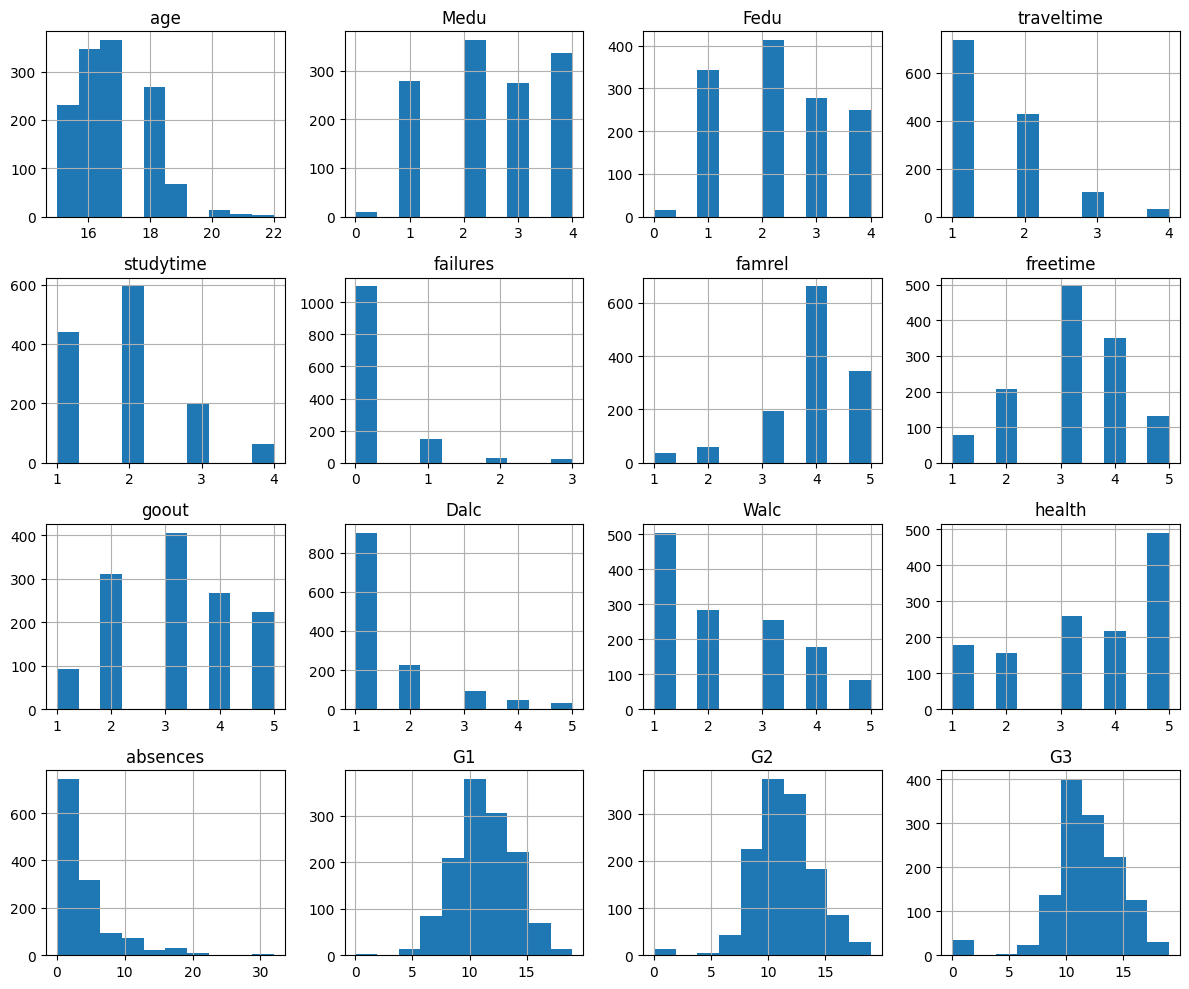

In [12]:
print(st.shape)
print(st.dtypes)

print("\nПропуски:")
print(st.isnull().sum())
print('Дубликаты:', st.duplicated().sum())

print("\nОписательная статистика:")
print(st.describe(include='all'))

st.select_dtypes(include=[np.number]).hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

In [ ]:
num_cols_with_nan = ['Medu', 'freetime']
for col in num_cols_with_nan:
    st[col].fillna(st[col].median(), inplace=True)

cat_cols_with_nan = ['famsup', 'higher']
for col in cat_cols_with_nan:
    mode_val = st[col].mode()
    if not mode_val.empty:
        st[col].fillna(mode_val[0], inplace=True)

st.drop_duplicates(inplace=True)

print(st.shape)

print("\nПропуски:")
print(st.isnull().sum())
print('Дубликаты:', st.duplicated().sum())

(701, 33)

Пропуски:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
Дубликаты: 0


C:\Users\borga\AppData\Local\Temp\ipykernel_14128\3489045529.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  st[col].fillna(st[col].median(), inplace=True)
C:\Users\borga\AppData\Local\Temp\ipykernel_14128\3489045529.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [15]:
def grade_category(g):
    if g <= 10:
        return 'low'
    elif g <= 15:
        return 'medium'
    else:
        return 'high'

st['G3_cat'] = st['G3'].apply(grade_category)
y = st['G3_cat']
X = st.drop(columns=['G3', 'G3_cat']) 

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score
import time

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LogisticRegression': {
        'pipeline': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__multi_class': ['ovr', 'multinomial'],
            'clf__solver': ['lbfgs', 'saga']
        }
    },
    'kNN': {
        'pipeline': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())]),
        'params': {
            'clf__n_neighbors': [3, 5, 7, 9],
            'clf__weights': ['uniform', 'distance'],
            'clf__metric': ['euclidean', 'manhattan']
        }
    },
    'SVM': {
        'pipeline': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__kernel': ['linear', 'rbf'],
            'clf__decision_function_shape': ['ovr']
        }
    }
}


results = []

for name, config in models.items():
    print(f"\nПодбор гиперпараметров для {name}...")
    
    start_time = time.time()
    grid = GridSearchCV(
        config['pipeline'],
        config['params'],
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train, y_train)
    fit_time = time.time() - start_time

    y_pred = grid.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'Accuracy': acc,
        'F1-weighted': f1,
        'Fit Time (s)': fit_time,
        'CV Best Score': grid.best_score_
    })

    print(f"{name} — F1: {f1:.4f}, Accuracy: {acc:.4f}, Время: {fit_time:.2f} с")


Подбор гиперпараметров для LogisticRegression...


c:\Users\borga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression — F1: 0.7810, Accuracy: 0.7801, Время: 5.50 с

Подбор гиперпараметров для kNN...
kNN — F1: 0.6454, Accuracy: 0.6525, Время: 0.46 с

Подбор гиперпараметров для SVM...
SVM — F1: 0.7706, Accuracy: 0.7730, Время: 0.24 с



Итоговое сравнение моделей:
                Model  Accuracy  F1-weighted  Fit Time (s)  CV Best Score
0  LogisticRegression  0.780142     0.780966      5.496689       0.829137
1                 kNN  0.652482     0.645357      0.463977       0.701621
2                 SVM  0.773050     0.770636      0.236196       0.815744


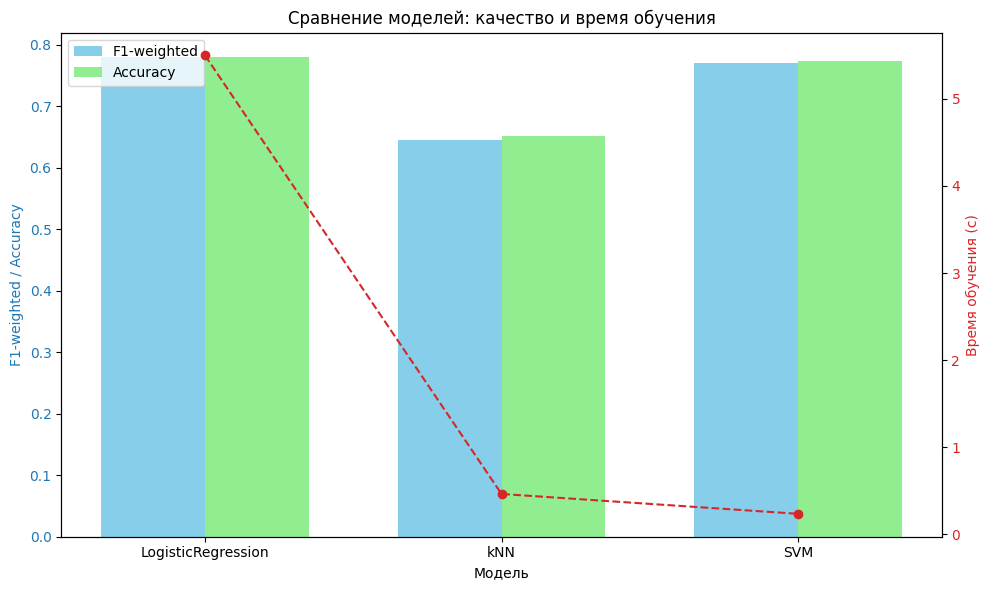

In [19]:
results_df = pd.DataFrame(results)
print("\nИтоговое сравнение моделей:")
print(results_df[['Model', 'Accuracy', 'F1-weighted', 'Fit Time (s)', 'CV Best Score']])

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Модель')
ax1.set_ylabel('F1-weighted / Accuracy', color=color)
x = np.arange(len(results_df))
width = 0.35

ax1.bar(x - width/2, results_df['F1-weighted'], width, label='F1-weighted', color='skyblue')
ax1.bar(x + width/2, results_df['Accuracy'], width, label='Accuracy', color='lightgreen')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Model'])
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Время обучения (с)', color=color)
ax2.plot(results_df['Model'], results_df['Fit Time (s)'], color=color, marker='o', linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Сравнение моделей: качество и время обучения')
plt.tight_layout()
plt.show()